In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1. Problem Statement
Download datasets

Goal: Identify different groups of customers based on their income and spending behaviour to help businesses target marketing strategies.

In [29]:
df=pd.read_csv("store_customers.csv")
df.columns
print(df)

     CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0          1000      M  39.0                59.9                    58.0
1          1001      M  34.0                48.4                    37.0
2          1002      F  40.0                70.5                    26.0
3          1003      F  47.0                81.1                    30.0
4          1004      F  33.0                42.1                    58.0
..          ...    ...   ...                 ...                     ...
995        1995      M  80.0               133.3                     1.0
996        1996      M  44.0                82.6                    40.0
997        1997      F  46.0                67.7                    26.0
998        1998      F  28.0                45.7                    59.0
999        1999      M  67.0               107.8                     1.0

[1000 rows x 5 columns]



## 2. Dataset Description
Dataset contains:

CustomerID

Gender

Age

Annual Income

Spending Score

In [52]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 982 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              982 non-null    int64  
 1   Gender                  982 non-null    int64  
 2   Age                     982 non-null    float64
 3   Annual Income (k$)      982 non-null    float64
 4   Spending Score (1-100)  982 non-null    float64
 5   Cluster                 982 non-null    int32  
dtypes: float64(3), int32(1), int64(2)
memory usage: 49.9 KB


(982, 6)

## 3. Data Cleaning

Steps performed:

• Checked missing values

• Checked duplicate rows

• Dropped missing values

• Converted Gender to numerical format

In [31]:
df.isnull().sum()


CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df=df.dropna()


In [53]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

## 4 Exploratory Data Analysis

(explanation markdown)

Age Distribution
(histplot)

Annual Income Distribution
(histplot)

Spending Score Distribution
(histplot)

Income vs Spending Score
(scatterplot)

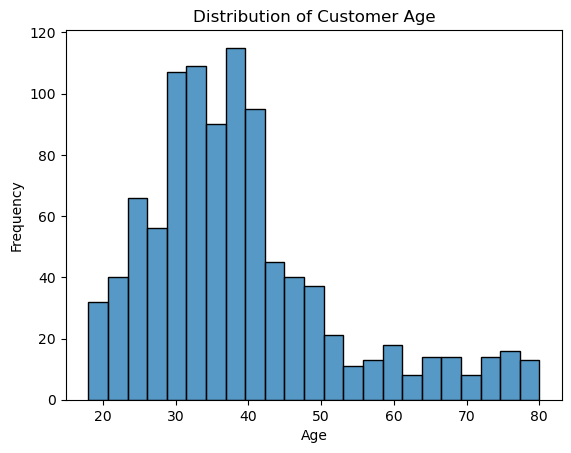

In [35]:
sns.histplot(df["Age"])
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

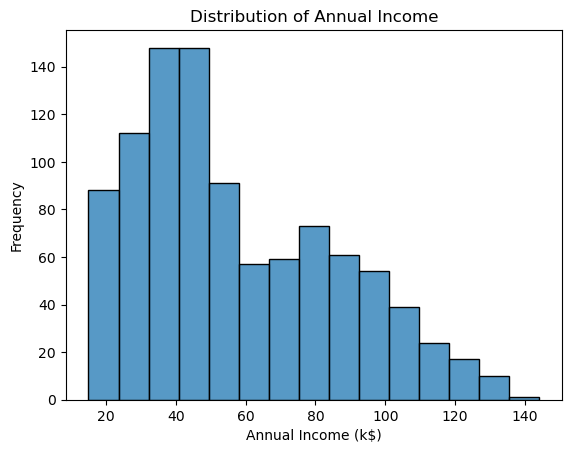

In [36]:
sns.histplot(df["Annual Income (k$)"])
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

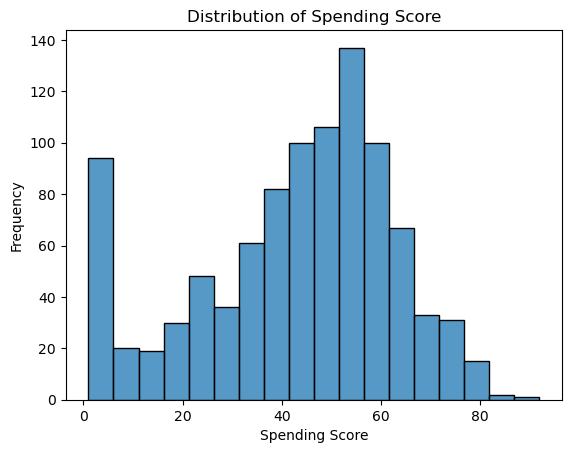

In [37]:
sns.histplot(df["Spending Score (1-100)"])
plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

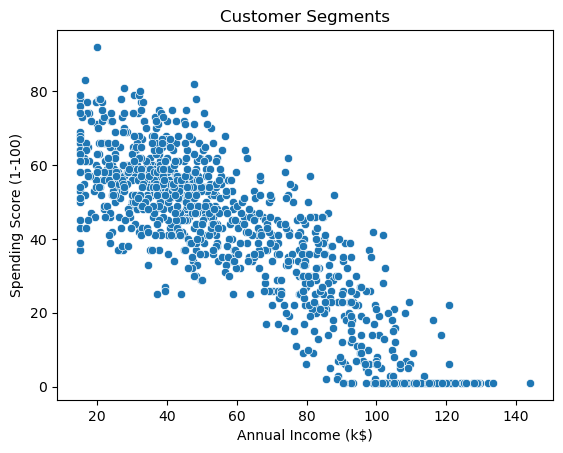

In [38]:
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"])
plt.title("Customer Segments")
plt.show()

## 5. Feature Selection

Selected features:

Age

Annual Income

Spending Score

These features represent customer purchasing power and behaviour.

In [40]:
x = df[["Age","Annual Income (k$)","Spending Score (1-100)"]]

## 6. Feature Scaling

K-Means clustering is distance based algorithm.

Therefore features must be scaled before training.

In [41]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [42]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

## 7. Finding Optimal Clusters (Elbow Method)

Elbow method helps determine the optimal number of clusters
by measuring WCSS (Within Cluster Sum of Squares).

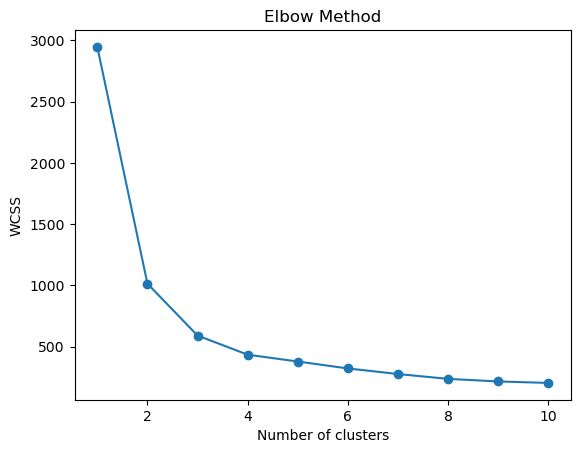

In [43]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [44]:
for k in range(2,11):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(x_scaled)
    print(k,silhouette_score(x_scaled,labels))

2 0.5725833626981489
3 0.48471315371880985
4 0.38095978419512944
5 0.3314674456977127
6 0.32339693991865026
7 0.32204138323066633
8 0.3238020938071556
9 0.3071538029133043
10 0.2995644543543769


In [45]:
kmeans=KMeans(n_clusters=5)
labels=kmeans.fit_predict(x_scaled)
df["Cluster"]=labels

## 8. Cluster Visualization
Visualizing clusters based on Annual Income and Spending Score

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

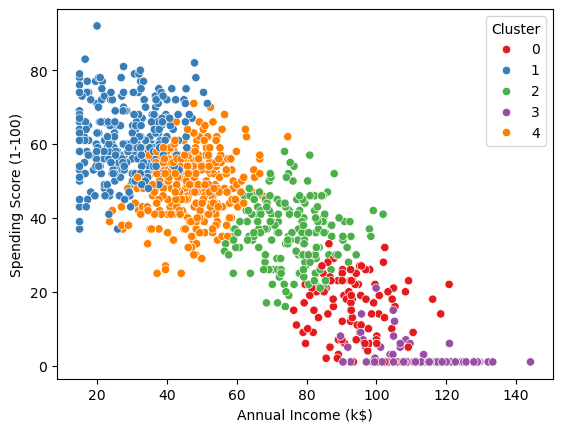

In [46]:
sns.scatterplot(x=df["Annual Income (k$)"],
               y=df["Spending Score (1-100)"],
               hue=df["Cluster"],palette="Set1"  )

In [47]:
df.groupby(df["Cluster"]).mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,1639.792079,0.445545,52.811881,93.958416,15.584158
1,1466.177700,0.487805,26.968641,28.660279,61.181185
2,1463.427027,0.502703,42.891892,75.730811,35.891892
3,1869.142857,0.440476,71.333333,112.426190,2.547619
4,1412.753846,0.480000,34.633846,46.540308,48.769231


In [48]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)


In [49]:
print(x_pca.shape)

(982, 2)


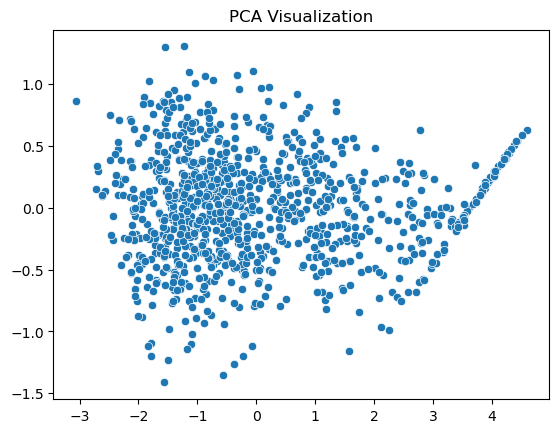

In [50]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])
plt.title("PCA Visualization")
plt.show()

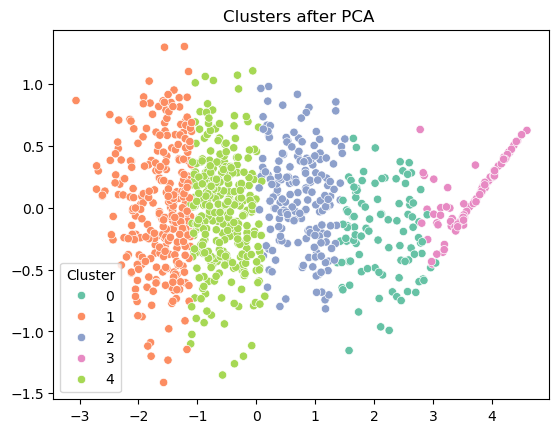

In [51]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=df["Cluster"],palette="Set2")
plt.title("Clusters after PCA ")
plt.show()

## 9. Cluster Interpretation

Cluster 0 → High income, high spending customers  
Target: Premium products and exclusive offers

Cluster 1 → Low income, low spending customers  
Target: Discounts and budget-friendly offers

Cluster 2 → Moderate income, moderate spending customers  
Target: Regular promotions and loyalty programs

Cluster 3 → Young high spenders  
Target: Fashion and lifestyle products

Cluster 4 → Budget conscious customers  
Target: Value deals and seasonal discount

## 10. Conclusion

K-Means clustering successfully segmented customers into different groups.

Businesses can use these clusters to:

• Target marketing campaigns

• Personalize offers

• Improve customer retention